In [ ]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [3]:
# Import libraries
import warnings
import pandas as pd
import numpy as np
import pickle
import sys; sys.path.insert(0, '..')

from src.lgd_builder import (
    compute_actual_lgd, fit_survival_model, fit_resolution_type_model,
    fit_cf_hazard_model, fit_cf_amount_models, build_unsolved_default_fwl_data,
    compute_est_lgd
) 
from src.fwl_model import (
    spearman_rank_corr, point_biserial_corr, kruskal_algor, composite_score
)

pd.options.display.float_format = '{:.3f}'.format
np.set_printoptions(suppress = True)
warnings.simplefilter(action ='ignore', category = pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category = RuntimeWarning)
warnings.filterwarnings('ignore', category = UserWarning)

In [4]:
# Import default data
df_account = pd.read_parquet(
    '../data/processed/default_account.parquet',
    engine = 'pyarrow'
)

# Import cashflow data
df_cashflow = pd.read_parquet(
    '../data/processed/default_cashflow.parquet',
    engine = 'pyarrow'
)

# Import MEV(s) data
df_mev = pd.read_parquet(
    '../data/raw/mev_transformed.parquet',
    engine = 'pyarrow'
)

In [5]:
# Constant parameters
# Default information
ACC_ID_COL = "acc_id" #Primary key
RESOLUTION_COL = "resolved" #Resolution flag --> (0, 1)
EIR_COL = "eir" #EIR column for discount factor
AMOUNT_COL = "amount" #Cashflow amount column
MONTH_SINCE_DEFAULT = "month_since_default" #Month since default for discount times
EAD_COL = "ead" #Exposure at default

In [6]:
# Find MEV(s) correlation
res_type_corr = kruskal_algor(df_account, df_mev, "resolution_type")
res_time_corr = spearman_rank_corr(df_account, df_cashflow, df_mev, "time_to_resolution")
cf_amt_corr = spearman_rank_corr(df_account, df_cashflow, df_mev, "log_amount_rate")
cf_hazrd_corr = point_biserial_corr(df_account, df_cashflow, df_mev, "has_cf")

# Combine result
corr_result = pd.concat(
    [res_type_corr, res_time_corr, cf_amt_corr, cf_hazrd_corr],
    axis = 1
).reset_index(names = "mev")

# Show table
corr_result.head(5)

,mev,resolution_type_stat,resolution_type_p_value,time_to_resolution_stat,time_to_resolution_p_value,log_amount_rate_stat,log_amount_rate_p_value,has_cf_stat,has_cf_p_value
0,GDP,0.002,0.000,-0.804,0.000,-0.121,0.000,-0.006,0.000
1,FDI,0.003,0.000,-0.809,0.000,-0.261,0.000,0.080,0.000
2,HHD,0.005,0.000,-0.919,0.000,-0.289,0.000,0.110,0.000
3,COPD,0.000,0.023,-0.390,0.000,0.066,0.000,-0.047,0.000
4,GOVD,0.004,0.000,-0.910,0.000,-0.291,0.000,0.133,0.000


In [7]:
# MEV(s) Features selection
composite_score(corr_result)


MEV(s) Significant Score
BROMO_MA9M          : 90.33
BROMO_MA12M         : 89.58
GOVD_MA12M_LAG12M   : 89.43
BROMO_MA6M          : 89.35
BROMO_MA6M_LAG6M    : 89.11
BROMO_MA9M_LAG3M    : 88.90
BROMO_MA6M_LAG3M    : 88.69
WAGE_MA12M_LAG9M    : 88.63
BROMO_MA12M_LAG3M   : 88.60
GOVD_MA12M_LAG9M    : 88.54


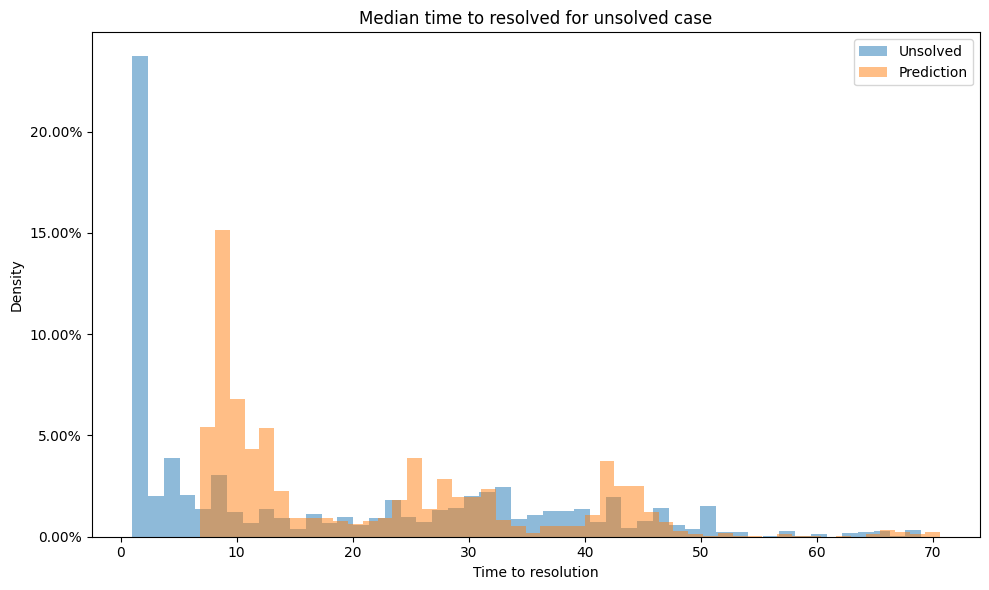

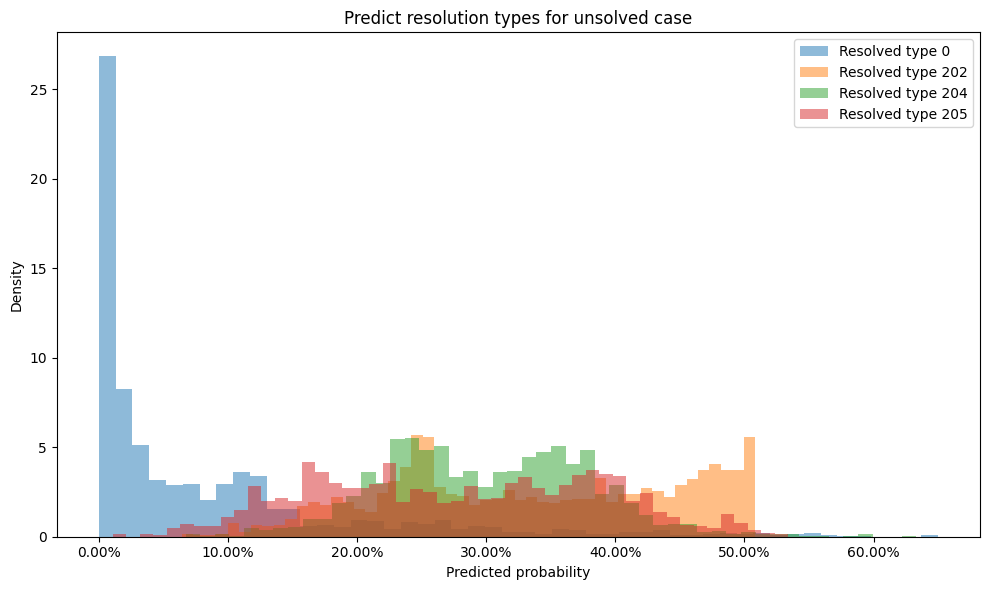

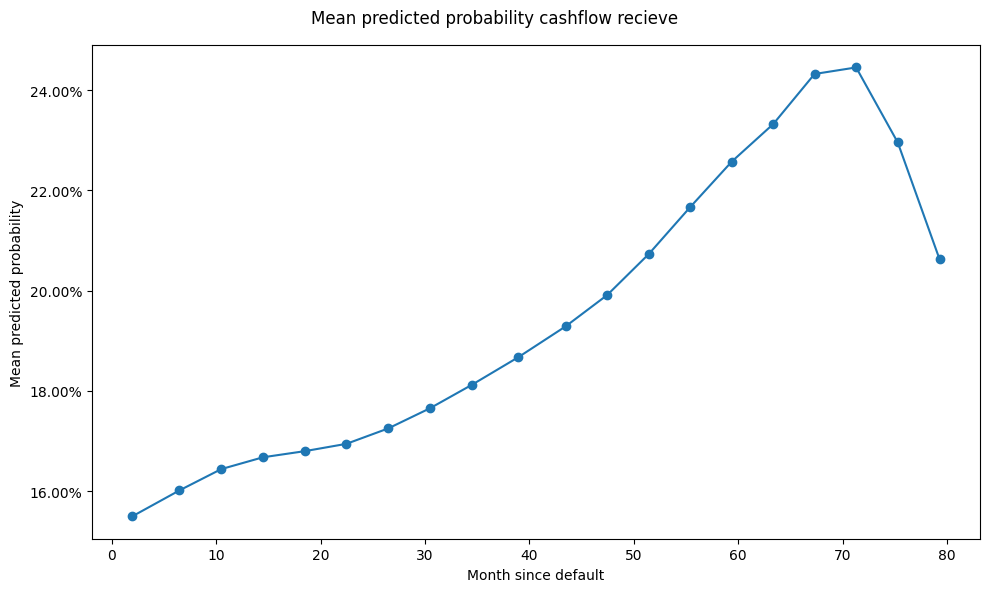

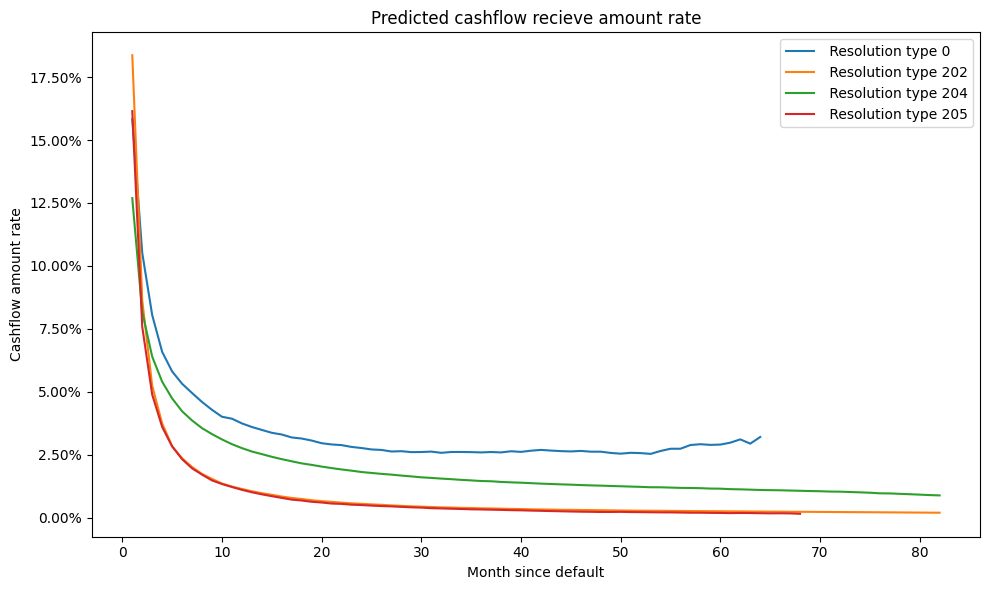

In [8]:
# Selected MEV(s)
FWL_FEATURES = ["BROMO_MA9M", "GOVD_MA12M_LAG12M"]

# Re-fitting model with FWL Consideration
aft, _ = fit_survival_model(df_account, df_mev, FWL_FEATURES) #Survival model for time to resolution
clf_type, le_type, _ = fit_resolution_type_model(df_account, df_mev, FWL_FEATURES) #Classification model for resoluation type
cf_hazard_model, _ = fit_cf_hazard_model(df_account, df_cashflow, df_mev, FWL_FEATURES) #Classification model for cashflow recieve
cf_amount_models, _ = fit_cf_amount_models(df_account, df_cashflow, df_mev, FWL_FEATURES) #Regression model for cashflow amount recieve

In [9]:
# Compute actual LGD for resolved cases
df_account = compute_actual_lgd(
    df_accounts = df_account,
    df_cashflow = df_cashflow,
    acc_id_col = ACC_ID_COL,
    resolution_col = RESOLUTION_COL,
    eir_col = EIR_COL,
    amount_col = AMOUNT_COL,
    month_s_col = MONTH_SINCE_DEFAULT,
    ead_col = EAD_COL
)

=== Processing ===
[INFO]: Actual LGD for resolved cases
=== Result ===
Resolution type   0 - LGD: 0.45%
Resolution type 202 - LGD: 55.68%
Resolution type 204 - LGD: 62.41%
Resolution type 205 - LGD: 90.48%


In [10]:
# Build cashflow profile for unsolved cases
df_cashflow_unsolved, prob_res_type = build_unsolved_default_fwl_data(
    df_accounts = df_account,
    aft = aft,
    clf_type = clf_type,
    le_type = le_type,
    cf_hazard_model = cf_hazard_model,
    cf_amount_models = cf_amount_models,
    df_mev = df_mev,
    fwl_features = FWL_FEATURES
)

In [11]:
# FWL LGD
fwl_lgd = compute_est_lgd(
    df_account,
    df_cashflow,
    df_cashflow_unsolved,
    prob_res_type,
    outfile = True,
    file_name = "fwl_lgd"
)

[INFO]: Export - '..data/processed/fwl_lgd.parquet'

Unbias LGD Model
Total default accounts        : 24,808
    Resolved cases            : 23,481
    Unsolved cases            : 1,327
Resolved portfolio LGD        : 57.84%
    Resolution type 0         : 0.45%
    Resolution type 202       : 55.68%
    Resolution type 204       : 62.41%
    Resolution type 205       : 90.48%
Unsolved portfolio LGD        : 66.09%
    Resolution type 0         : 40.81%
    Resolution type 202       : 79.69%
    Resolution type 204       : 45.04%
    Resolution type 205       : 61.00%
Unbias portfolio LGD          : 58.22%
    Default status 100        Resolution type 0          : 3.86%
    Default status 100        Resolution type 202        : 52.46%
    Default status 100        Resolution type 204        : 61.81%
    Default status 100        Resolution type 205        : 56.85%
    Default status 202        Resolution type 202        : 57.84%
    Default status 204        Resolution type 204        

In [12]:
# Export models
all_models = [aft, clf_type, le_type, cf_hazard_model, cf_amount_models]
models_names = ["fwl_aft_model", "fwl_res_type_model", "fwl_res_type_encoder", "fwl_cf_hazard_model", "fwl_cf_amount_model"]

for name, mde in zip(models_names, all_models):
    with open(f"../model/{name}.pkl", "wb") as f:
        pickle.dump(mde, f)
    print(f"[INFO]: Export - '../model/{name}.pkl'")

[INFO]: Export - '../model/fwl_aft_model.pkl'
[INFO]: Export - '../model/fwl_res_type_model.pkl'
[INFO]: Export - '../model/fwl_res_type_encoder.pkl'
[INFO]: Export - '../model/fwl_cf_hazard_model.pkl'
[INFO]: Export - '../model/fwl_cf_amount_model.pkl'
